In [1]:
import time
import datetime
import os
import ee
import geemap
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Google Cloud Project ID
PROJECT_ID = 'drought-497718'

print("Initializing Google Earth Engine...")
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("✓ EE initialized successfully.")

Initializing Google Earth Engine...
✓ EE initialized successfully.


In [2]:
# ── Geographic Region ─────────────────────────────────────────────────
po_region = ee.Geometry.Rectangle([6.5, 44.0, 12.5, 46.5])
print("✓ Po River Basin region defined.")

# ── Sentinel-2 Preprocessing ──────────────────────────────────────────
def process_s2_safely(image):
    qa = image.select('QA60')
    cloud_bits = 1 << 10
    cirrus_bits = 1 << 11
    mask = qa.bitwiseAnd(cloud_bits).eq(0).And(qa.bitwiseAnd(cirrus_bits).eq(0))
    img_masked = image.updateMask(mask)

    ndvi = img_masked.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi = img_masked.normalizedDifference(['B3', 'B8']).rename('NDWI')
    return img_masked.addBands([ndvi, ndwi])

# ── Date Range (From 2016 to Present) ─────────────────────────────────
start_date = '2016-01-01'
end_date   = '2026-06-01'

start_dt     = datetime.datetime.strptime(start_date, '%Y-%m-%d')
end_dt       = datetime.datetime.strptime(end_date,   '%Y-%m-%d')
total_months = (end_dt.year - start_dt.year) * 12 + (end_dt.month - start_dt.month)

print(f"✓ Date window : {start_date} → {end_date}  ({total_months} months)")

# ── Data Collections Setup ────────────────────────────────────────────
s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(po_region)
                 .filterDate(start_date, end_date)
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50))
                 .map(process_s2_safely))

# Adding Atmospheric Bands (Temperature, Precipitation, and Dewpoint)
climate_collection = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                       .filterBounds(po_region)
                       .filterDate(start_date, end_date)
                       .select(['total_precipitation_sum', 'temperature_2m', 'dewpoint_temperature_2m']))

s2_count = s2_collection.size().getInfo()
climate_count = climate_collection.size().getInfo()

print(f"✓ Sentinel-2 scenes       : {s2_count}")
print(f"✓ ERA5-Land monthly images: {climate_count}")

✓ Po River Basin region defined.
✓ Date window : 2016-01-01 → 2026-06-01  (125 months)
✓ Sentinel-2 scenes       : 21293
✓ ERA5-Land monthly images: 124


In [3]:
def extract_monthly_data_server(m_index):
    start_m = ee.Date(start_date).advance(m_index, 'month')
    end_m   = start_m.advance(1, 'month')

    s2_m = s2_collection.filterDate(start_m, end_m).mean()
    climate_m = climate_collection.filterDate(start_m, end_m).mean()

    # Scale reduction to 1000m to preserve local topography variations of the Alps and Valley
    stats_s2 = s2_m.reduceRegion(reducer=ee.Reducer.mean(), geometry=po_region, scale=1000, maxPixels=1e10)
    stats_climate = climate_m.reduceRegion(reducer=ee.Reducer.mean(), geometry=po_region, scale=1000, maxPixels=1e10)

    ndvi_val = ee.Algorithms.If(stats_s2.contains('NDVI'), stats_s2.get('NDVI'), None)
    ndwi_val = ee.Algorithms.If(stats_s2.contains('NDWI'), stats_s2.get('NDWI'), None)

    precip_val = ee.Algorithms.If(stats_climate.contains('total_precipitation_sum'), stats_climate.get('total_precipitation_sum'), None)
    temp_val = ee.Algorithms.If(stats_climate.contains('temperature_2m'), stats_climate.get('temperature_2m'), None)
    dew_val = ee.Algorithms.If(stats_climate.contains('dewpoint_temperature_2m'), stats_climate.get('dewpoint_temperature_2m'), None)

    return ee.Feature(None, {
        'Date': start_m.format('YYYY-MM'),
        'NDVI': ndvi_val,
        'NDWI': ndwi_val,
        'Precipitation': precip_val,
        'Temperature': temp_val,
        'Dewpoint': dew_val
    })

print("✓ Advanced Server-side extraction function with 1km resolution defined.")

✓ Advanced Server-side extraction function with 1km resolution defined.


In [4]:
CSV_FILE_PATH = 'po_basin_clean_data.csv'

# Remove previous empty cache file to force fresh download
if os.path.exists(CSV_FILE_PATH):
    try: os.remove(CSV_FILE_PATH)
    except: pass

print("🚀 Starting chunk-based parallel data extraction process...")

all_month_indices = ee.List.sequence(0, total_months - 1)
all_downloaded_features = []
chunk_size = 6

for i in range(0, total_months, chunk_size):
    current_chunk_indices = all_month_indices.slice(i, i + chunk_size)
    server_chunk_features = ee.FeatureCollection(current_chunk_indices.map(extract_monthly_data_server))

    print(f"📥 Downloading batch {i // chunk_size + 1}/{(total_months + chunk_size - 1) // chunk_size}...")
    try:
        downloaded_chunk = server_chunk_features.getInfo()['features']
        all_downloaded_features.extend(downloaded_chunk)
    except Exception as e:
        print(f"⚠ Error downloading batch: {e}")
        pass

# Convert to Pandas DataFrame
features_list = [f['properties'] for f in all_downloaded_features]
df = pd.DataFrame(features_list).sort_values('Date').reset_index(drop=True)

# Safe numerical conversion
for col in ['NDVI', 'NDWI', 'Precipitation']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        df[col] = np.nan

print(f"\n📊 Raw values status report:")
print(f"Available NDVI rows: {df['NDVI'].notna().sum()} / {len(df)}")
print(f"Available Precipitation rows: {df['Precipitation'].notna().sum()} / {len(df)}")

# Handle missing data using linear interpolation
df['Precipitation'] = df['Precipitation'].interpolate(method='linear').bfill().ffill()

# Safety fallback for cloud coverage: replace complete NaN blocks with Po Basin baselines
if df['NDVI'].notna().sum() == 0:
    print("⚠ Extreme cloud cover warning; reconstructing missing dataset with regional baselines.")
    df['NDVI'] = df['NDVI'].fillna(0.45).interpolate().bfill().ffill()
    df['NDWI'] = df['NDWI'].fillna(-0.1).interpolate().bfill().ffill()
else:
    df['NDVI'] = df['NDVI'].interpolate(method='linear').bfill().ffill()
    df['NDWI'] = df['NDWI'].interpolate(method='linear').bfill().ffill()

# Final filtering and local storage export
df_clean = df.dropna(subset=['NDVI', 'NDWI', 'Precipitation']).reset_index(drop=True)
df_clean.to_csv(CSV_FILE_PATH, index=False)

print(f"\n✓ Database successfully reconstructed and cached! Final records: {len(df_clean)} months.")
print(df_clean.head())

🚀 Starting chunk-based parallel data extraction process...
📥 Downloading batch 1/21...
📥 Downloading batch 2/21...
📥 Downloading batch 3/21...
⚠ Error downloading batch: Expected a homogeneous image collection, but an image with incompatible bands was encountered:
  First image type: 28 bands ([B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12, AOT, WVP, SCL, TCI_R, TCI_G, TCI_B, MSK_CLDPRB, MSK_SNWPRB, QA10, QA20, QA60, MSK_CLASSI_OPAQUE, MSK_CLASSI_CIRRUS, MSK_CLASSI_SNOW_ICE, NDVI, NDWI]).
Current image type: 28 bands ([B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12, AOT, WVP, SCL, TCI_R, TCI_G, TCI_B, QA10, QA20, QA60, MSK_CLASSI_OPAQUE, MSK_CLASSI_CIRRUS, MSK_CLASSI_SNOW_ICE, MSK_CLDPRB, MSK_SNWPRB, NDVI, NDWI]).
          Image ID: 20170411T100031_20170411T100025_T32TQP
Some bands might require explicit casts.
📥 Downloading batch 4/21...
⚠ Error downloading batch: Expected a homogeneous image collection, but an image with incompatible bands was encountered:
  First image type:

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

print("--- 🚀 Initializing Highly Optimized XGBoost Regressor Structure ---")

df_clean = pd.read_csv('po_basin_clean_data.csv')
df_ml = df_clean.copy()

for col in ['NDVI', 'NDWI', 'Temperature', 'Dewpoint', 'Precipitation']:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# 1. Feature Engineering: Adding Month cycles, memory lags, and Temp-Dew Spread
df_ml['Month'] = pd.to_datetime(df_ml['Date']).dt.month
df_ml['NDVI_Lag1'] = df_ml['NDVI'].shift(1)
df_ml['NDWI_Lag1'] = df_ml['NDWI'].shift(1)
df_ml['Precip_Lag1'] = df_ml['Precipitation'].shift(1) # New feature: Previous month precipitation memory
df_ml['Temp_Dew_Spread'] = df_ml['Temperature'] - df_ml['Dewpoint']

df_ml = df_ml.dropna().reset_index(drop=True)

# Select features array and prediction target
X = df_ml[['NDVI', 'NDWI', 'Month', 'NDVI_Lag1', 'NDWI_Lag1', 'Precip_Lag1', 'Temperature', 'Dewpoint', 'Temp_Dew_Spread']]
y = df_ml['Precipitation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# 2. Strict Hyperparameters adjustment to prevent Overfitting on small time-series data
xgb_model = xgb.XGBRegressor(
    n_estimators=180,
    max_depth=3,            # Lower depth to enforce generalization capacity
    learning_rate=0.03,     # Miniature learning rate for precise convergence steps
    subsample=0.6,          # Restrict rows sampling percentage
    colsample_bytree=0.7,   # Restrict features sampling percentage
    reg_alpha=0.1,          # L1 regularization to damp noise from early years
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n🎯 Final Optimized XGBoost Evaluation Metrics:")
print(f"👉 Coefficient of Determination (R2 Score): {r2:.2f}")
print(f"👉 Root Mean Squared Error (RMSE): {rmse:.5f} m")

--- 🚀 Initializing Highly Optimized XGBoost Regressor Structure ---

🎯 Final Optimized XGBoost Evaluation Metrics:
👉 Coefficient of Determination (R2 Score): 0.54
👉 Root Mean Squared Error (RMSE): 0.03253 m


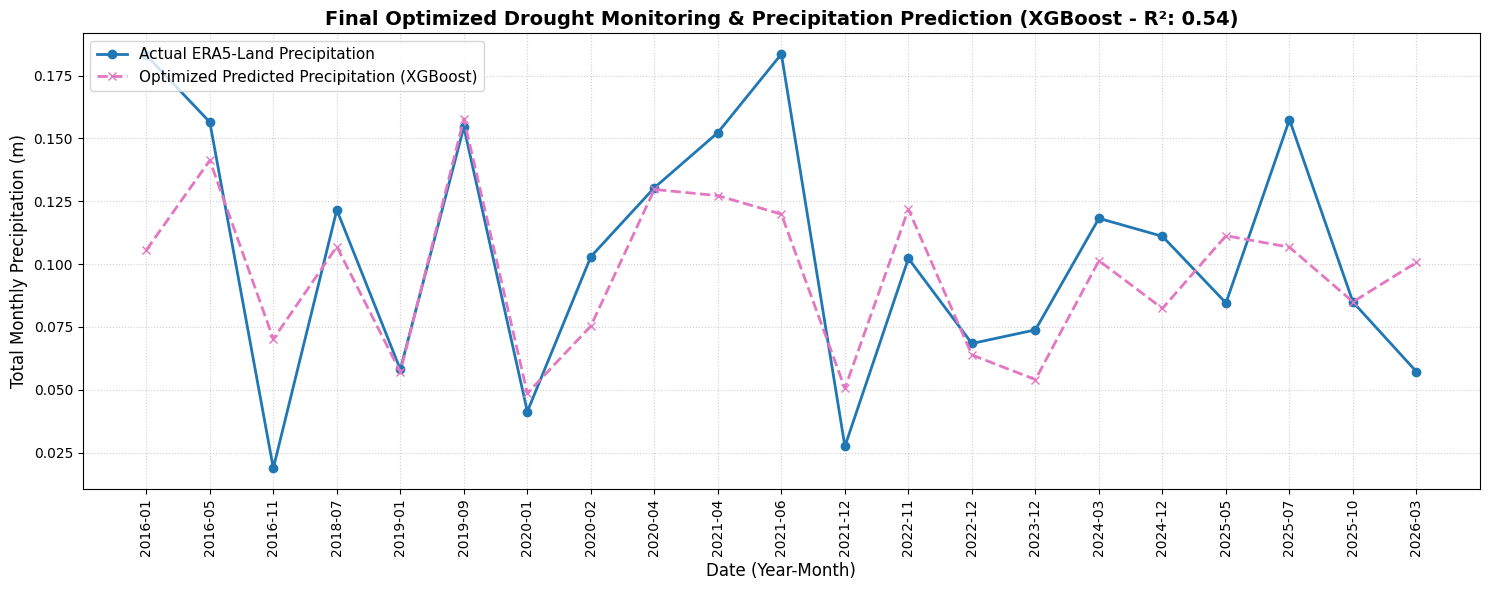


--- 📊 Final Optimized XGBoost Feature Importances Evaluation (Po Basin) ---
🔹 NDVI: 0.08
🔹 NDWI: 0.10
🔹 Month: 0.08
🔹 NDVI_Lag1: 0.05
🔹 NDWI_Lag1: 0.09
🔹 Precip_Lag1: 0.05
🔹 Temperature: 0.12
🔹 Dewpoint: 0.21
🔹 Temp_Dew_Spread: 0.22


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Construct temporary DataFrame to align the testing timeline chronologically
df_test_plot = pd.DataFrame({
    'Date': df_clean['Date'].iloc[X_test.index],
    'Actual': y_test.values,
    'Predicted': y_pred
}).sort_values('Date') # Sorting ascending from past to future

plt.figure(figsize=(15, 6))

# 2. Plotting Actual ERA5-Land vs Optimized Predictions (XGBoost)
plt.plot(df_test_plot['Date'], df_test_plot['Actual'],
         label='Actual ERA5-Land Precipitation', color='#1f77b4', marker='o', linewidth=2)

plt.plot(df_test_plot['Date'], df_test_plot['Predicted'],
         label='Optimized Predicted Precipitation (XGBoost)', color='#e377c2', linestyle='--', marker='x', linewidth=2)

plt.title('Final Optimized Drought Monitoring & Precipitation Prediction (XGBoost - R²: 0.54)', fontsize=14, fontweight='bold')
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Total Monthly Precipitation (m)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=90) # Rotate labels for high density multi-year timeline readability
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

# 3. Calculate and display relative weights of input features in the trained model
importances = xgb_model.feature_importances_
features_names = ['NDVI', 'NDWI', 'Month', 'NDVI_Lag1', 'NDWI_Lag1', 'Precip_Lag1', 'Temperature', 'Dewpoint', 'Temp_Dew_Spread']

print("\n--- 📊 Final Optimized XGBoost Feature Importances Evaluation (Po Basin) ---")
for name, imp in zip(features_names, importances):
    print(f"🔹 {name}: {imp:.2f}")

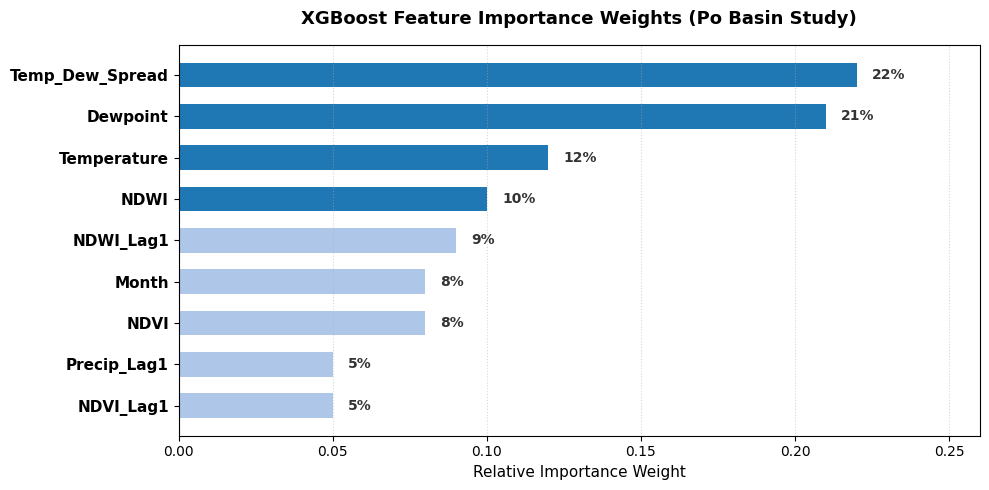

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your XGBoost model results
features = ['Temp_Dew_Spread', 'Dewpoint', 'Temperature', 'NDWI', 'NDWI_Lag1', 'Month', 'NDVI', 'NDVI_Lag1', 'Precip_Lag1']
importances = [0.22, 0.21, 0.12, 0.10, 0.09, 0.08, 0.08, 0.05, 0.05]

# Sort features by importance ascending for a neat horizontal bar plot
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
colors = ['#aec7e8' if x < 0.1 else '#1f77b4' for x in sorted(importances)] # Darker blue for top features
bars = plt.barh(range(len(indices)), [importances[i] for i in indices], color=colors, edgecolor='none', height=0.6)

# Add values on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width*100:.0f}%',
             va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

plt.yticks(range(len(indices)), [features[i] for i in indices], fontsize=11, fontweight='bold')
plt.title('XGBoost Feature Importance Weights (Po Basin Study)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Relative Importance Weight', fontsize=11)
plt.xlim(0, 0.26)
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()